In [1]:
# Cell 1
!pip install easyocr rapidfuzz textblob gspread ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 17.5 MB/s eta 0:00:00


In [3]:

import os
import re
import cv2
import pandas as pd
import easyocr
from rapidfuzz import fuzz
from textblob import Word
import gspread
from google.colab import auth
from google.auth import default
from sklearn.metrics import classification_report
from ultralytics import YOLO

from google.colab import drive
drive.mount('/content/drive')

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)


Mounted at /content/drive


In [4]:
FOLDER_PATH = "/content/drive/MyDrive/Technology-dataset/ads_project/raw_images/ads-ds/"
GOOGLE_SHEET_NAME = "tech-dataset"
THRESHOLD = 0.60

print("Loading OCR and YOLO Models (this might take a moment)...")
reader = easyocr.Reader(['en'], gpu=True)
yolo_model = YOLO('yolov8n.pt')
print("Models loaded successfully!")


Loading OCR and YOLO Models (this might take a moment)...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Models loaded successfully!


In [5]:
IMPORTANT_KEYWORDS = {
    "sony", "samsung", "apple", "oneplus", "realme", "xiaomi",
    "redmi", "boat", "jbl", "lenovo", "asus", "hp", "dell",
    "earbuds", "laptop", "camera", "tablet", "smart phone", "smartphone", "watch"
}

STOPWORDS = {
    "the", "is", "and", "to", "in", "of", "on", "with",
    "this", "that", "from", "your", "now", "buy", "offer",
    "sale", "free", "limited", "shop", "only", "today"
}

YOLO_CLASS_MAPPING = {
    "cell phone": "smart phone",
    "tv": "display",
    "monitor": "display",
    "clock": "watch"
}


In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    return text

def correct_word(word):
    try:
        return str(Word(word).correct())
    except:
        return word

def extract_ocr_keywords(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return set()

    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, img_bin = cv2.threshold(img_gray, 150, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    results = reader.readtext(img_bin)
    text = " ".join([res[1] for res in results])
    clean_words = clean_text(text).split()

    keywords = set()
    for word in clean_words:
        if len(word) > 2 and word not in STOPWORDS:
            keywords.add(correct_word(word))
    return keywords

def extract_yolo_objects(image_path):
    results = yolo_model(image_path, verbose=False)
    detected_objects = set()

    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            class_name = yolo_model.names[cls_id].lower()

            mapped_name = YOLO_CLASS_MAPPING.get(class_name, class_name)
            detected_objects.add(mapped_name)

    return detected_objects


In [7]:
def fuzzy_match_score(found_keywords, expected_keywords):
    score = 0
    total_weight = 0

    for expected_word in expected_keywords:
        expected_word = expected_word.strip().lower()
        best_match = 0

        for found_word in found_keywords:
            similarity = fuzz.partial_ratio(expected_word, found_word) / 100
            best_match = max(best_match, similarity)

        weight = 2 if expected_word in IMPORTANT_KEYWORDS else 1

        score += best_match * weight
        total_weight += weight

    if total_weight == 0:
        return 0

    return score / total_weight

def classify_ad(score):
    if score >= 0.60:
        return '✅LEGIT [AD TEXT AND OBJECTS MATCH THE ADVERTISER\'S CLAIMS]'
    elif score >= 0.40:
        return '⚠️SUSPICIOUS [SOME KEYWORDS MATCH, BUT OTHERS ARE MISSING OR \'NOISE\' IN TEXT IS TOO HIGH. REQUIRE MANUAL REVIEW!]'
    else:
        return '❌FAKE [ALMOST NO CORELATION BETWEEN ADVERTISED KEYWORDS AND WHAT IS ACTUALLY IN THE PICTURE.]'


In [9]:
!pip install transformers accelerate open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00


In [10]:
import torch
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
import open_clip

# Check for GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

print("Loading BLIP model (image captioning)...")
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large").to(device)
print("BLIP model loaded successfully!")

print("Loading CLIP model (image-text similarity)...")
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
clip_model.to(device)
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')
print("CLIP model loaded successfully!")

Using device: cpu
Loading BLIP model (image captioning)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BLIP model loaded successfully!
Loading CLIP model (image-text similarity)...


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP model loaded successfully!


In [11]:
def generate_image_caption(image_path):
    try:
        raw_image = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
        return None

    # Preprocess the image for the BLIP model
    inputs = blip_processor(raw_image, return_tensors="pt").to(device)

    # Generate the caption
    out = blip_model.generate(**inputs, max_length=50, num_beams=4)

    # Decode the generated caption
    caption = blip_processor.decode(out[0], skip_special_tokens=True)
    return caption


In [12]:
def calculate_clip_similarity(image_path, text_queries):
    try:
        raw_image = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
        return 0.0 # Return 0 similarity if image not found

    # Preprocess and encode image
    image_input = clip_preprocess(raw_image).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = clip_model.encode_image(image_input)

    # Tokenize and encode text queries
    text_tokens = clip_tokenizer(text_queries).to(device)
    with torch.no_grad():
        text_features = clip_model.encode_text(text_tokens)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate cosine similarity
    # The result is already cosine similarity because features are normalized
    similarity_scores = (image_features @ text_features.T).squeeze(0)

    # Return the maximum similarity if comparing against multiple text queries
    return similarity_scores.max().item()

In [17]:
def calculate_final_score(image_path, advertiser_keywords, ocr_keywords, yolo_keywords):
    # 2. Calculate ocr_score
    ocr_score = fuzzy_match_score(ocr_keywords, advertiser_keywords)

    # 3. Calculate yolo_score
    yolo_score = fuzzy_match_score(yolo_keywords, advertiser_keywords)

    # 4. Generate image caption
    caption = generate_image_caption(image_path)

    # 5. Calculate CLIP image-advertiser similarity
    clip_image_advertiser_similarity = calculate_clip_similarity(image_path, list(advertiser_keywords))

    # 6. Calculate caption_score
    caption_score = 0.0
    if caption and caption.strip():
        caption_score = fuzzy_match_score(set(caption.split()), advertiser_keywords)

    # 7. Calculate the final_score as a weighted sum
    final_score = (
        (ocr_score * 0.45) +
        (yolo_score * 0.05) +
        (clip_image_advertiser_similarity * 0.20) +
        (caption_score * 0.30)
    )

    # 8. Return the final_score
    return final_score

In [18]:
# Cell 7: Integrated Multi-Modal Analysis
sheet = gc.open(GOOGLE_SHEET_NAME)
worksheet = sheet.get_worksheet(0)
df = pd.DataFrame(worksheet.get_all_records())

y_true = []
y_pred = []

print("🚀 Starting Integrated Multi-Modal Authenticity Analysis...\n")

for index, row in df.iterrows():
    image_name = row["Image_Name"]
    image_path = os.path.join(FOLDER_PATH, image_name)

    # Get Expected Keywords
    advertiser_keywords = set([k.strip().lower() for k in str(row["Advertiser_Keywords"]).split(",")])
    actual_label = row["Expected_Label"]

    if not os.path.exists(image_path):
        print(f"❌ Missing Image File: {image_name}")
        continue

    # --- INTEGRATED SCORING ---
    # 1. Extract base features
    ocr_keywords = extract_ocr_keywords(image_path)
    yolo_keywords = extract_yolo_objects(image_path)
    blip_caption = generate_image_caption(image_path)
    clip_sim = calculate_clip_similarity(image_path, list(advertiser_keywords))

    # 2. Get the weighted final score (Includes CLIP and BLIP)
    score = calculate_final_score(image_path, advertiser_keywords, ocr_keywords, yolo_keywords)

    # 3. Classify based on the new weighted score
    raw_prediction = classify_ad(score)
    # --------------------------

    # Map to "GOOD" or "MISLEADING"
    if raw_prediction.startswith('✅LEGIT'):
        display_prediction = 'GOOD'
    elif raw_prediction.startswith('⚠️SUSPICIOUS') or raw_prediction.startswith('❌FAKE'):
        display_prediction = 'MISLEADING'
    else:
        display_prediction = raw_prediction

    y_true.append(actual_label)
    y_pred.append(display_prediction)

    # Detailed Output
    print("=================================")
    print(f"Image: {image_name}")
    print(f"🔍 OCR: {list(ocr_keywords)[:5]}")
    print(f"📸 YOLO: {list(yolo_keywords)}")
    print(f"📝 BLIP:  \"{blip_caption}\"")
    print(f"🔗 CLIP:  {round(clip_sim, 2)}")
    print(f"📊 Final Multi-Modal Score: {round(score, 2)}")
    print(f"🤖 Prediction: {display_prediction} | 🎯 Actual: {actual_label}")

# Final Report
print("\n" + "="*35)
print("🏆 FINAL SYSTEM RESULTS (MULTI-MODAL) 🏆")
print("="*35)
accuracy = sum([1 for t, p in zip(y_true, y_pred) if t == p]) / len(y_true)
print(f"Overall Accuracy: {round(accuracy * 100, 2)}%\n")
print("Classification Report:")
print(classification_report(y_true, y_pred))

🚀 Starting Integrated Multi-Modal Authenticity Analysis...

Image: camera_1.jpg
🔍 OCR: ['camera', 'off', 'reallygreatsite']
📸 YOLO: []
📝 BLIP:  "a black and gold poster with a camera on a pedestal"
🔗 CLIP:  0.21
📊 Final Multi-Modal Score: 0.53
🤖 Prediction: MISLEADING | 🎯 Actual: MISLEADING
Image: camera_2.jpg
🔍 OCR: ['off', 'may', 'mode', 'ultra', 'tinge']
📸 YOLO: []
📝 BLIP:  "an advertisement for a camera sale with a picture of a camera"
🔗 CLIP:  0.26
📊 Final Multi-Modal Score: 0.53
🤖 Prediction: MISLEADING | 🎯 Actual: MISLEADING
Image: camera_3.jpg
🔍 OCR: ['tone', 'consectatut', 'order', 'god', 'magna']
📸 YOLO: ['smart phone']
📝 BLIP:  "the black friday sale is on gadgets up to 80 % off"
🔗 CLIP:  0.25
📊 Final Multi-Modal Score: 0.63
🤖 Prediction: GOOD | 🎯 Actual: GOOD
Image: camera_4.jpg
🔍 OCR: ['only', 'contact', 'ionbamtterataroornrntonehe', 'pad', 'finer']
📸 YOLO: []
📝 BLIP:  "a purple and yellow poster with a photo of a digital camera"
🔗 CLIP:  0.28
📊 Final Multi-Modal Score: 0.

In [16]:
def analyze_ad_application(image_file, keywords_input):
    image_path = os.path.join(FOLDER_PATH, image_file)

    if not os.path.exists(image_path):
        print(f"❌ Error: Image file not found at {image_path}")
        return None, None

    # Parse user input keywords
    advertiser_keywords = set([k.strip().lower() for k in keywords_input.split(',')])

    print(f"\n--- 🚀 Deep Multi-Modal Analysis: {image_file} ---")
    print(f"📝 Input Keywords: {advertiser_keywords}")

    # 1. Extract Base Features
    ocr_keywords = extract_ocr_keywords(image_path)
    yolo_keywords = extract_yolo_objects(image_path)

    # 2. Get AI Model specific outputs for transparency
    blip_caption = generate_image_caption(image_path)
    clip_sim = calculate_clip_similarity(image_path, list(advertiser_keywords))

    # 3. Calculate Integrated Score (Weighted sum of OCR, YOLO, CLIP, BLIP)
    score = calculate_final_score(image_path, advertiser_keywords, ocr_keywords, yolo_keywords)

    # 4. Classify based on updated thresholds
    prediction = classify_ad(score)

    # --- UPDATED DETAILED OUTPUT ---
    print(f"🔍 OCR Found:  {list(ocr_keywords)[:8]}")
    print(f"📸 YOLO Found: {list(yolo_keywords)}")
    print(f"📝 BLIP Caption: \"{blip_caption}\"")
    print(f"🔗 CLIP Similarity: {round(clip_sim, 2)}")
    print(f"📊 FINAL MATCH SCORE: {round(score, 2)}")
    print(f"🤖 SYSTEM PREDICTION: {prediction}")
    print("---------------------------------------")

    return score, prediction

# --- Execution ---
image_file_input = input("Enter the image file name (e.g., 'camera_4.jpg'): ")
keywords_input = input("Enter keywords separated by commas (e.g., 'digital, camera'): ")

score, classification = analyze_ad_application(image_file_input, keywords_input)

if score is not None:
    print(f"\n✅ Final Analysis for '{image_file_input}':")
    print(f"Score: {round(score, 2)} | Status: {classification}")

Enter the image file name (e.g., 'camera_4.jpg'): /content/drive/MyDrive/Colab Notebooks/test_ad.png
Enter keywords separated by commas (e.g., 'digital, camera'): 'iphone', 'oled', 'smart phone', 'display', 'retina', 'apple', 'screen

--- 🚀 Deep Multi-Modal Analysis: /content/drive/MyDrive/Colab Notebooks/test_ad.png ---
📝 Input Keywords: {"'iphone'", "'screen", "'retina'", "'display'", "'apple'", "'oled'", "'smart phone'"}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


🔍 OCR Found:  ['pro', 'dutordooipinama', 'front', 'sac', 'starting', 'phone', 'screen', 'cold']
📸 YOLO Found: []
📝 BLIP Caption: "a close up of a cell phone with a price tag on it"
🔗 CLIP Similarity: 0.26
📊 FINAL MATCH SCORE: 0.61
🤖 SYSTEM PREDICTION: ✅LEGIT [AD TEXT AND OBJECTS MATCH THE ADVERTISER'S CLAIMS]
---------------------------------------

✅ Final Analysis for '/content/drive/MyDrive/Colab Notebooks/test_ad.png':
Score: 0.61 | Status: ✅LEGIT [AD TEXT AND OBJECTS MATCH THE ADVERTISER'S CLAIMS]


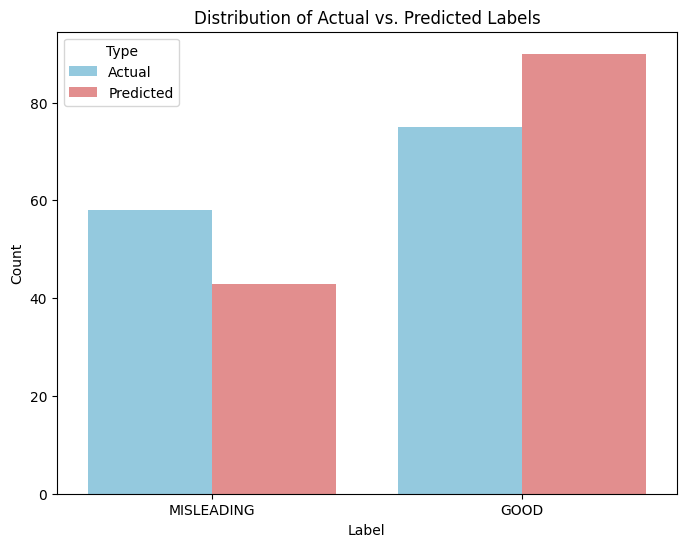

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for plotting
plot_df = pd.DataFrame({'Actual': y_true, 'Predicted': y_pred})

# Melt the DataFrame to easily compare actual vs. predicted
melted_df = plot_df.melt(var_name='Type', value_name='Label')

plt.figure(figsize=(8, 6))
sns.countplot(data=melted_df, x='Label', hue='Type', palette={'Actual': 'skyblue', 'Predicted': 'lightcoral'})
plt.title('Distribution of Actual vs. Predicted Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [23]:
!pip install -q streamlit
!npm install -g localtunnel
print('Streamlit and localtunnel installed successfully!')

⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 1s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇Streamlit and localtunnel installed successfully!


In [33]:
%%writefile app.py
import streamlit as st
import os
import re
import cv2
import torch
import pandas as pd
import easyocr
import open_clip
from PIL import Image
from rapidfuzz import fuzz
from textblob import Word
from ultralytics import YOLO
from transformers import BlipProcessor, BlipForConditionalGeneration

# --- CACHED MODEL INITIALIZATION ---
@st.cache_resource
def load_models():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())
    yolo_model = YOLO('yolov8n.pt')
    blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
    blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large").to(device)
    clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
    clip_model.to(device)
    clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')
    return device, reader, yolo_model, blip_processor, blip_model, clip_model, clip_preprocess, clip_tokenizer

device, reader, yolo_model, blip_processor, blip_model, clip_model, clip_preprocess, clip_tokenizer = load_models()

# --- CONSTANTS ---
IMPORTANT_KEYWORDS = {"sony", "samsung", "apple", "oneplus", "realme", "xiaomi", "redmi", "boat", "jbl", "lenovo", "asus", "hp", "dell", "earbuds", "laptop", "camera", "tablet", "smart phone", "smartphone", "watch"}
STOPWORDS = {"the", "is", "and", "to", "in", "of", "on", "with", "this", "that", "from", "your", "now", "buy", "offer", "sale", "free", "limited", "shop", "only", "today"}
YOLO_CLASS_MAPPING = {"cell phone": "smart phone", "tv": "display", "monitor": "display", "clock": "watch"}

# --- UTILITY FUNCTIONS ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    return text

def correct_word(word):
    try: return str(Word(word).correct())
    except: return word

def extract_ocr_keywords(image_path):
    img = cv2.imread(image_path)
    if img is None: return set()
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, img_bin = cv2.threshold(img_gray, 150, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    results = reader.readtext(img_bin)
    text = " ".join([res[1] for res in results])
    clean_words = clean_text(text).split()
    keywords = {correct_word(word) for word in clean_words if len(word) > 2 and word not in STOPWORDS}
    return keywords

def extract_yolo_objects(image_path):
    results = yolo_model(image_path, verbose=False)
    detected_objects = set()
    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            class_name = yolo_model.names[cls_id].lower()
            detected_objects.add(YOLO_CLASS_MAPPING.get(class_name, class_name))
    return detected_objects

def generate_image_caption(image_path):
    raw_image = Image.open(image_path).convert('RGB')
    inputs = blip_processor(raw_image, return_tensors="pt").to(device)
    out = blip_model.generate(**inputs, max_length=50, num_beams=4)
    return blip_processor.decode(out[0], skip_special_tokens=True)

def calculate_clip_similarity(image_path, text_queries):
    raw_image = Image.open(image_path).convert('RGB')
    image_input = clip_preprocess(raw_image).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = clip_model.encode_image(image_input)
        text_tokens = clip_tokenizer(text_queries).to(device)
        text_features = clip_model.encode_text(text_tokens)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    similarity_scores = (image_features @ text_features.T).squeeze(0)
    return similarity_scores.max().item()

def fuzzy_match_score(found_keywords, expected_keywords):
    score, total_weight = 0, 0
    for expected_word in expected_keywords:
        expected_word = expected_word.strip().lower()
        best_match = max([fuzz.partial_ratio(expected_word, fw) / 100 for fw in found_keywords] + [0])
        weight = 2 if expected_word in IMPORTANT_KEYWORDS else 1
        score += best_match * weight
        total_weight += weight
    return score / total_weight if total_weight > 0 else 0

def classify_ad(score):
    if score >= 0.60: return '✅ GENUINE', "success"
    elif score >= 0.45: return '⚠️ MISLEADING', "warning"
    else: return '❌ FAKE', "error"

def calculate_final_score(image_path, advertiser_keywords):
    ocr_k = extract_ocr_keywords(image_path)
    yolo_k = extract_yolo_objects(image_path)
    caption = generate_image_caption(image_path)
    clip_sim = calculate_clip_similarity(image_path, list(advertiser_keywords))
    ocr_score = fuzzy_match_score(ocr_k, advertiser_keywords)
    yolo_score = fuzzy_match_score(yolo_k, advertiser_keywords)
    caption_score = fuzzy_match_score(set(caption.split()), advertiser_keywords) if caption else 0
    final_score = (ocr_score * 0.45) + (yolo_score * 0.05) + (clip_sim * 0.20) + (caption_score * 0.30)
    return final_score, ocr_k, yolo_k, caption, clip_sim

# --- STREAMLIT UI ---
st.title("🛡️ Ad Authenticity Dashboard")
st.markdown("Upload an advertisement image and provide expected keywords to verify its authenticity using Multi-Modal AI.")

uploaded_file = st.file_uploader("Choose an ad image...", type=["jpg", "jpeg", "png", "webp"])
keywords_input = st.text_input("Enter keywords (comma-separated)", placeholder="apple, iphone, screen, oled")

if uploaded_file and keywords_input:
    st.image(uploaded_file, caption='Uploaded Image', use_container_width=True)
    if st.button("Run Analysis"):
        with st.spinner('Analyzing Multi-Modal features...'):
            with open("temp_ad.png", "wb") as f:
                f.write(uploaded_file.getbuffer())

            keywords = set([k.strip().lower() for k in keywords_input.split(',')])
            score, ocr_found, yolo_found, caption, clip_sim = calculate_final_score("temp_ad.png", keywords)
            label, status_type = classify_ad(score)

            st.divider()
            st.subheader("Analysis Results")
            col1, col2 = st.columns(2)
            col1.metric("Final Match Score", f"{round(score, 2)}")

            if status_type == "success": st.success(label)
            elif status_type == "warning": st.warning(label)
            else: st.error(label)

            with st.expander("View Feature Breakdown"):
                st.write(f"📊 FINAL MATCH SCORE: {round(score, 2)}")
                st.write(f"**🔍 OCR Keywords:** {', '.join(list(ocr_found)[:10])}")
                st.write(f"**📸 YOLO Objects:** {', '.join(list(yolo_found))}")
                st.write(f"**📝 BLIP Caption:** \"{caption}\"")
                st.write(f"**🔗 CLIP Similarity:** {round(clip_sim, 2)}")

Overwriting app.py


In [ ]:
# Run Streamlit in the background
!nohup streamlit run app.py &

# Get the public IP address (used as the password for localtunnel)
print("Your public IP address for localtunnel login is:")
!curl ipv4.icanhazip.com

# Expose port 8501 using localtunnel in the background
!npx localtunnel --port 8501 &

nohup: appending output to 'nohup.out'
Your public IP address for localtunnel login is:
34.24.212.149
⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://pretty-bags-find.loca.lt
